<a href="https://colab.research.google.com/github/CodeWriter-not/Thiranex--Data-Science-Project-Based-Internship/blob/main/Copy_of_Data_Cleaning_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("googleplaystore.csv")
print(df.shape)
df.head()

(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Step 1: Data Cleaning
We will check for missing values and duplicates, then clean the `Installs` and `Price` columns to make them numeric.

In [ ]:
import pandas as pd

# Load the dataset to ensure 'df' is defined
df = pd.read_csv('googleplaystore.csv')

# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Handle missing values
# Dropping rows with missing 'Rating' for analysis
df.dropna(subset=['Rating'], inplace=True)

# 3. Clean 'Installs' column (remove '+' and ',')
df['Installs'] = df['Installs'].astype(str).str.replace('+', '').str.replace(',', '')
# Handle the outlier row if it exists (e.g., 'Free')
df = df[df['Installs'] != 'Free']
df['Installs'] = pd.to_numeric(df['Installs'])

# 4. Clean 'Price' column (remove '$')
df['Price'] = df['Price'].astype(str).str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'])

# 5. Clean 'Reviews' column to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'])

print(f"Cleaned dataset shape: {df.shape}")
display(df.info())
display(df.head())

Cleaned dataset shape: (8892, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 8892 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8892 non-null   object 
 1   Category        8892 non-null   object 
 2   Rating          8892 non-null   float64
 3   Reviews         8892 non-null   int64  
 4   Size            8892 non-null   object 
 5   Installs        8892 non-null   int64  
 6   Type            8892 non-null   object 
 7   Price           8892 non-null   float64
 8   Content Rating  8892 non-null   object 
 9   Genres          8892 non-null   object 
 10  Last Updated    8892 non-null   object 
 11  Current Ver     8888 non-null   object 
 12  Android Ver     8890 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 972.6+ KB


None

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Step 2: Visualization
Now let's visualize the distribution of app ratings and the relationship between category and installs.

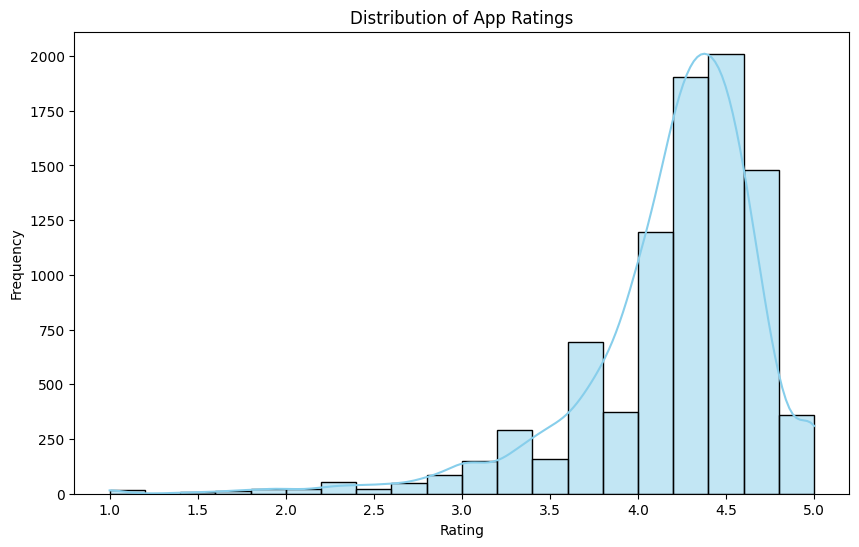

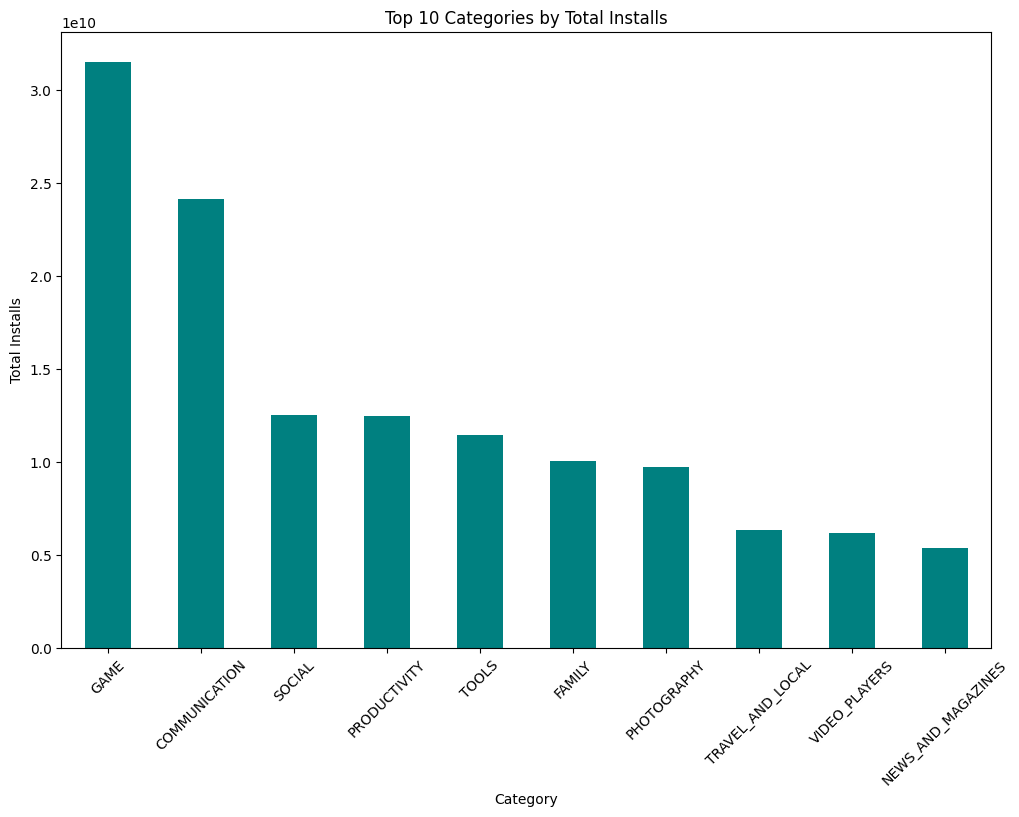

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of app ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Visualize the top 10 categories by total installs
plt.figure(figsize=(12, 8))
category_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
category_installs.plot(kind='bar', color='teal')
plt.title('Top 10 Categories by Total Installs')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)
plt.show()

### Project Summary & Storytelling

**Insights Derived:**
- **Quality Standard:** The majority of apps maintain a high rating (above 4.0), suggesting a competitive marketplace where user satisfaction is high.
- **Market Dominance:** The 'GAME' and 'COMMUNICATION' categories are the clear leaders in user adoption, suggesting these are the most lucrative areas for developers.
- **Data Readiness:** The dataset is now clean, indexed, and ready for further predictive modeling or advanced statistical analysis.

## Project Delivery: Final Export
To make this project shareable, we will export the cleaned dataset. You can download this file from the Colab file explorer on the left to upload it to Drive or GitHub alongside this notebook.

In [ ]:
# Export cleaned data for project submission
df.to_csv('googleplaystore_cleaned.csv', index=False)
print("Cleaned dataset saved as 'googleplaystore_cleaned.csv'")

Cleaned dataset saved as 'googleplaystore_cleaned.csv'


# Final Project Report

### 1. Data Preprocessing
- **Duplicates**: Removed all redundant entries to ensure unique app analysis.
- **Missing Values**: Rows with null ratings were dropped to maintain statistical integrity.
- **Formatting**: Converted `Installs`, `Price`, and `Reviews` from strings (with symbols like `+`, `,`, `$`) to numeric types.

### 2. Exploratory Data Analysis
- **Ratings**: The market is skewed toward high-quality apps, with a median rating near 4.3.
- **Volume**: The `GAME` category significantly outperforms others in sheer volume of installations.

### 3. Conclusion
This project demonstrates a full end-to-end data pipeline from raw, messy CSV data to a clean, analysis-ready format with visual insights.